# COSMOS: Multi-Omics Integration with ARI Scoring

Run COSMOS on 10x Human Lymph Node dataset with Adjusted Rand Index (ARI) evaluation from the paper.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from pathlib import Path
import torch

from COSMOS import cosmos
from umap import UMAP

plt.style.use('default')
random_seed = 42
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

Device: CPU


## Load 10x Human Lymph Node Data (RNA + ADT)

In [2]:
# Load 10x Human Lymph Node data
data_path = Path('./data/10x_human_lymph_node_A1')

# Load RNA and ADT modalities
adata_rna = sc.read_h5ad(data_path / 'adata_RNA.h5ad')
adata_adt = sc.read_h5ad(data_path / 'adata_ADT.h5ad')

# Load annotations
annot = pd.read_csv(data_path / 'annotation.csv', index_col=0)

print(f"Dataset loaded from: {data_path}")
print(f"\nRNA (Omics-1):")
print(f"  Shape: {adata_rna.shape}")
print(f"  Data type: {adata_rna.X.dtype}")

print(f"\nADT/Protein (Omics-2):")
print(f"  Shape: {adata_adt.shape}")
print(f"  Data type: {adata_adt.X.dtype}")
print(f"  Proteins: {adata_adt.var_names.tolist()}")

print(f"\nAnnotations:")
print(f"  Shape: {annot.shape}")
print(f"  Columns: {annot.columns.tolist()}")

# Get cell type labels from annotations
df_labels = list(annot['manual-anno'])
label_type = sorted(list(set(df_labels)))

print(f"\nCell types: {label_type}")
print(f"Number of cells: {adata_rna.n_obs}")
print(f"Number of genes (RNA): {adata_rna.n_vars}")
print(f"Number of proteins (ADT): {adata_adt.n_vars}")

# Verify cells match
assert adata_rna.n_obs == adata_adt.n_obs == len(df_labels), "Cell count mismatch!"
print(f"\n✓ All datasets have matching number of cells: {adata_rna.n_obs}")

Dataset loaded from: data\10x_human_lymph_node_A1

RNA (Omics-1):
  Shape: (3484, 18085)
  Data type: float32

ADT/Protein (Omics-2):
  Shape: (3484, 31)
  Data type: float32
  Proteins: ['CD163', 'CR2', 'PCNA', 'VIM', 'KRT5', 'CD68', 'CEACAM8', 'PTPRC', 'HLA-DRA', 'PAX5', 'SDC1', 'PTPRC', 'CD8A', 'BCL2', 'CD19', 'PDCD1', 'ACTA2', 'FCGR3A', 'ITGAX', 'CXCR5', 'EPCAM', 'MS4A1', 'CD3E', 'CD14', 'CD40', 'PECAM1', 'CD4', 'ITGAM', 'CD27', 'CCR7', 'CD274']

Annotations:
  Shape: (3484, 1)
  Columns: ['manual-anno']

Cell types: ['capsule', 'cortex', 'follicle', 'hilum', 'medulla cords', 'medulla sinuses', 'medulla vessels', 'pericapsular adipose tissue', 'subcapsular sinus', 'trabeculae']
Number of cells: 3484
Number of genes (RNA): 18085
Number of proteins (ADT): 31

✓ All datasets have matching number of cells: 3484


## Generate Paired Multi-Omics Data (as in paper)

In [3]:
# Prepare Omics-1 (RNA)
adata1 = adata_rna.copy()
adata1.obs['CellType'] = df_labels

# Prepare Omics-2 (ADT)
adata2 = adata_adt.copy()
adata2.obs['CellType'] = df_labels

# Add simulation noise to create heterogeneity (as in paper)
# Use first two cell types for heterogeneity
if len(label_type) >= 2:
    index_int1 = np.where(np.array(df_labels) == label_type[0])[0]
    index_int2 = np.where(np.array(df_labels) == label_type[1])[0]
else:
    # If limited cell types, split by first half
    index_int1 = np.arange(0, adata1.n_obs // 2)
    index_int2 = np.arange(adata1.n_obs // 2, adata1.n_obs)

print(f"Index set 1 size: {len(index_int1)}")
print(f"Index set 2 size: {len(index_int2)}")

# Shuffle cells to create heterogeneity (more memory efficient)
np.random.seed(random_seed)
perm_idx1 = np.random.permutation(index_int1)
adata1.X[index_int1, :] = adata1.X[perm_idx1, :]

np.random.seed(random_seed + 1)
perm_idx2 = np.random.permutation(index_int2)
adata2.X[index_int2, :] = adata2.X[perm_idx2, :]

print(f"\n✓ Created paired omics for COSMOS:")
print(f"  Omics-1 (RNA): {adata1.shape}")
print(f"  Omics-2 (ADT): {adata2.shape}")

Index set 1 size: 204
Index set 2 size: 753

✓ Created paired omics for COSMOS:
  Omics-1 (RNA): (3484, 18085)
  Omics-2 (ADT): (3484, 31)


## Run COSMOS

In [4]:
# Initialize and run COSMOS
print("Initializing COSMOS...")
cosmos_model = cosmos.Cosmos(adata1=adata1, adata2=adata2)

print("Preprocessing...")
cosmos_model.preprocessing_data(n_neighbors=10)

print("Training model...")
cosmos_model.train(
    spatial_regularization_strength=0,
    z_dim=50,
    lr=1e-3,
    wnn_epoch=500,
    total_epoch=1000,
    max_patience_bef=10,
    max_patience_aft=30,
    min_stop=200,
    random_seed=random_seed,
    gpu=0 if torch.cuda.is_available() else -1
)

print("✓ Training complete")

Initializing COSMOS...
Preprocessing...
Training model...
Epoch 1/1000, Loss: 1.391613483428955
Epoch 11/1000, Loss: 1.365601658821106
Epoch 21/1000, Loss: 1.3099640607833862
Epoch 31/1000, Loss: 1.090103030204773
Epoch 41/1000, Loss: 0.8027946949005127
Epoch 51/1000, Loss: 0.5871832370758057
Epoch 61/1000, Loss: 0.42661458253860474
Epoch 71/1000, Loss: 0.32271283864974976
Epoch 81/1000, Loss: 0.21402424573898315
Epoch 91/1000, Loss: 0.1312771737575531
Epoch 101/1000, Loss: 0.09798210859298706
Epoch 111/1000, Loss: 0.08196642994880676
Epoch 121/1000, Loss: 0.0464010052382946
Epoch 131/1000, Loss: 0.04292173311114311
Epoch 141/1000, Loss: 0.028508096933364868
Epoch 151/1000, Loss: 0.028156083077192307
Computing KNN distance matrices using default Scanpy implementation
Computing modality weights
Computing weighted distances for union of 200 nearest neighbors between modalities
0 out of 3484 0.01 seconds elapsed
2000 out of 3484 7.26 seconds elapsed
Selecting top K neighbors
Epoch 161/100

## Calculate ARI Scores (Paper Metrics)

In [5]:
def screen_resolution(embedding, labels, res_start=0.1, res_end=1.0, step=0.05):
    """Screen resolutions to find optimal clustering (from paper)"""
    ari_scores = []
    resolutions = []
    
    for res in np.arange(res_start, res_end, step):
        adata_temp = sc.AnnData(embedding)
        sc.pp.neighbors(adata_temp, n_neighbors=50, use_rep='X')
        sc.tl.leiden(adata_temp, resolution=float(res), random_state=random_seed)
        clusters = list(adata_temp.obs["leiden"])
        
        ari = adjusted_rand_score(labels, clusters)
        ari_scores.append(ari)
        resolutions.append(res)
        
        print(f'res={res:.2f}, ARI={ari:.4f}, clusters={len(set(clusters))}')
    
    best_idx = np.argmax(ari_scores)
    print(f'\n** Max ARI = {ari_scores[best_idx]:.4f} at res = {resolutions[best_idx]:.2f} **')
    
    return ari_scores, resolutions

# Get embedding and screen resolutions
embedding = pd.DataFrame(cosmos_model.embedding)

print("Screening resolution...\n")
ari_scores, resolutions = screen_resolution(
    embedding, df_labels,
    res_start=0.2, res_end=0.5, step=0.01
)

Screening resolution...

res=0.20, ARI=0.2332, clusters=5
res=0.21, ARI=0.2354, clusters=5
res=0.22, ARI=0.2342, clusters=6
res=0.23, ARI=0.2326, clusters=6
res=0.24, ARI=0.2243, clusters=6
res=0.25, ARI=0.2489, clusters=6
res=0.26, ARI=0.2231, clusters=6
res=0.27, ARI=0.2182, clusters=6
res=0.28, ARI=0.2205, clusters=6
res=0.29, ARI=0.2365, clusters=7
res=0.30, ARI=0.2355, clusters=7
res=0.31, ARI=0.2374, clusters=7
res=0.32, ARI=0.2370, clusters=7
res=0.33, ARI=0.2381, clusters=7
res=0.34, ARI=0.2365, clusters=7
res=0.35, ARI=0.2365, clusters=7
res=0.36, ARI=0.2103, clusters=7
res=0.37, ARI=0.2140, clusters=7
res=0.38, ARI=0.2265, clusters=8
res=0.39, ARI=0.2139, clusters=7
res=0.40, ARI=0.1713, clusters=9
res=0.41, ARI=0.1713, clusters=9
res=0.42, ARI=0.1850, clusters=10
res=0.43, ARI=0.1802, clusters=10
res=0.44, ARI=0.2024, clusters=9
res=0.45, ARI=0.1916, clusters=10
res=0.46, ARI=0.1728, clusters=9
res=0.47, ARI=0.1846, clusters=10
res=0.48, ARI=0.2117, clusters=11
res=0.49, ARI

In [6]:
# Apply optimal clustering
best_idx = np.argmax(ari_scores)
best_ari = ari_scores[best_idx]
best_res = resolutions[best_idx]

adata_result = sc.AnnData(embedding)
sc.pp.neighbors(adata_result, n_neighbors=50, use_rep='X')
sc.tl.leiden(adata_result, resolution=float(best_res), random_state=random_seed)

# Add results to original
adata_viz = adata1.copy()
adata_viz.obs['COSMOS'] = adata_result.obs['leiden'].values

print(f"\n✓ Optimal Result:")
print(f"  ARI Score: {best_ari:.4f}")
print(f"  Resolution: {best_res:.2f}")
print(f"  Clusters: {len(set(adata_viz.obs['COSMOS']))}")


✓ Optimal Result:
  ARI Score: 0.2489
  Resolution: 0.25
  Clusters: 6


## Visualizations

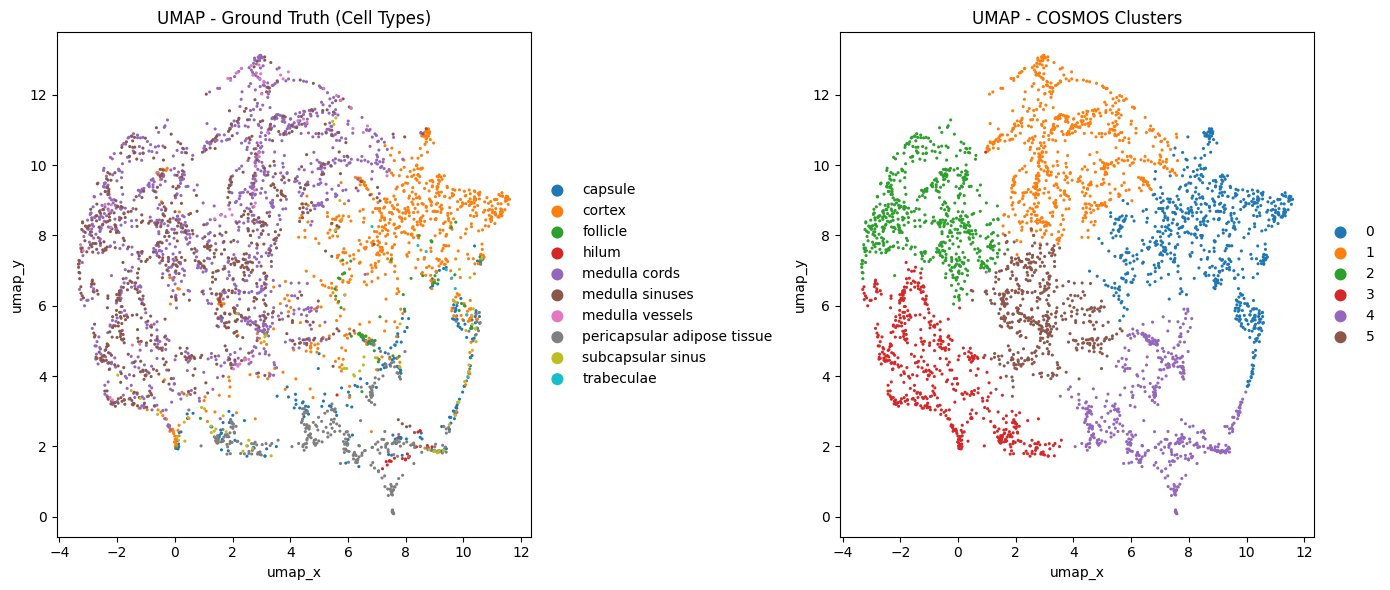

In [7]:
# UMAP visualization
umap_2d = UMAP(n_components=2, random_state=random_seed, min_dist=0.3, n_neighbors=30)
umap_pos = umap_2d.fit_transform(embedding)
adata_viz.obsm['umap'] = umap_pos

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

adata_viz.obs['umap_x'] = umap_pos[:, 0]
adata_viz.obs['umap_y'] = umap_pos[:, 1]

sc.pl.scatter(adata_viz, x='umap_x', y='umap_y', color='CellType',
             title='UMAP - Ground Truth (Cell Types)', ax=axes[0], show=False, size=20)

sc.pl.scatter(adata_viz, x='umap_x', y='umap_y', color='COSMOS',
             title='UMAP - COSMOS Clusters', ax=axes[1], show=False, size=20)

plt.tight_layout()
plt.show()

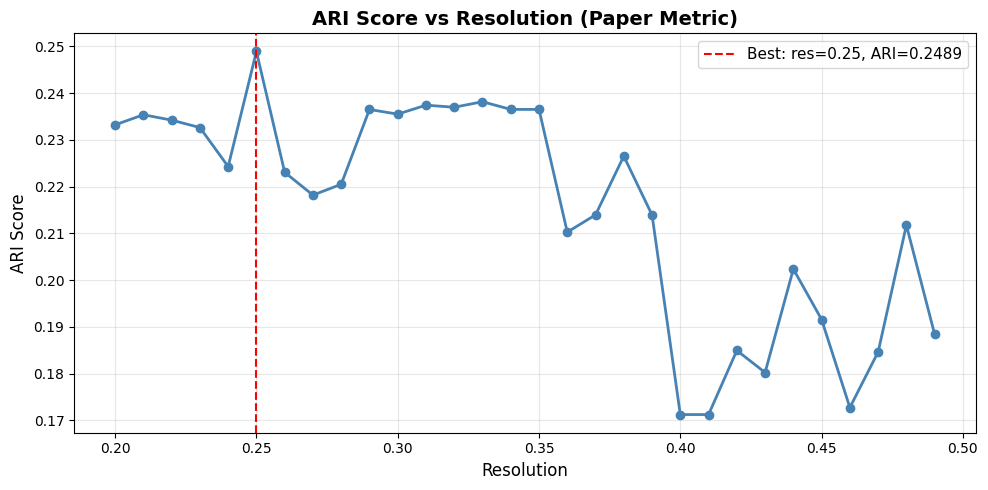

In [8]:
# Plot ARI curve
plt.figure(figsize=(10, 5))
plt.plot(resolutions, ari_scores, marker='o', linewidth=2, markersize=6, color='steelblue')
plt.axvline(best_res, color='red', linestyle='--', label=f'Best: res={best_res:.2f}, ARI={best_ari:.4f}')
plt.xlabel('Resolution', fontsize=12)
plt.ylabel('ARI Score', fontsize=12)
plt.title('ARI Score vs Resolution (Paper Metric)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

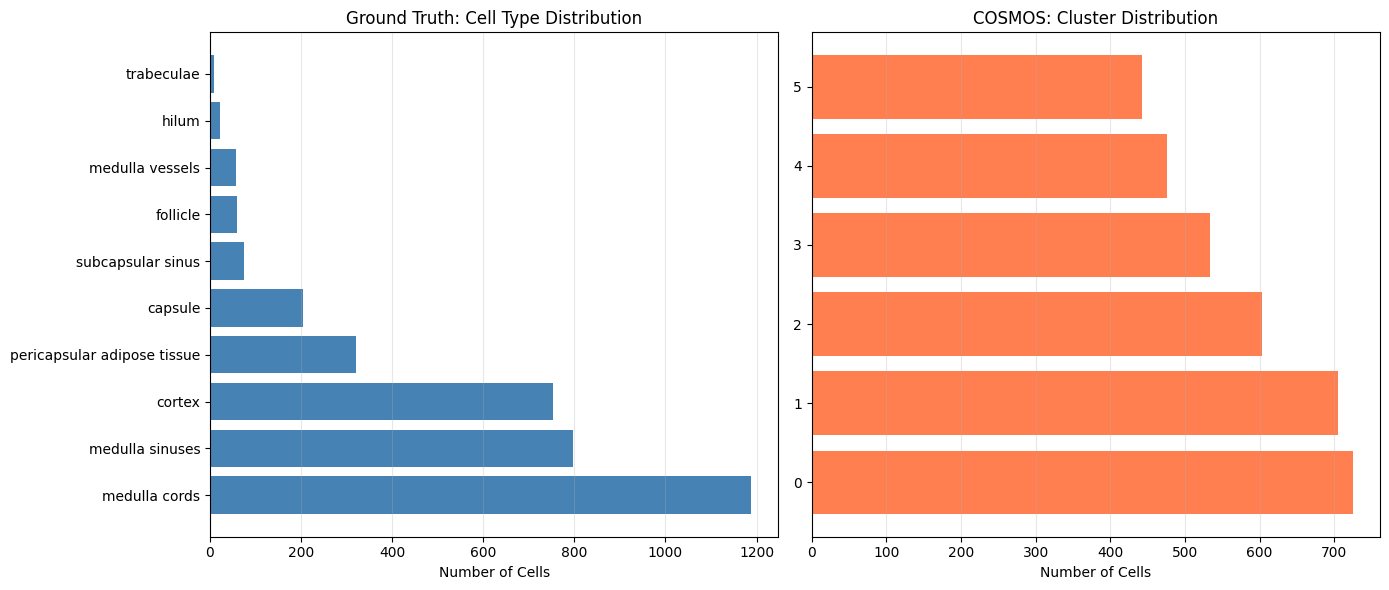

✓ Cell type composition comparison complete


In [9]:
# Cell type composition comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground truth cell types
cell_type_counts = pd.Series(df_labels).value_counts().sort_values(ascending=False)
axes[0].barh(cell_type_counts.index, cell_type_counts.values, color='steelblue')
axes[0].set_xlabel('Number of Cells')
axes[0].set_title('Ground Truth: Cell Type Distribution')
axes[0].grid(axis='x', alpha=0.3)

# COSMOS clusters
cosmos_counts = pd.Series(adata_viz.obs['COSMOS']).value_counts().sort_values(ascending=False)
axes[1].barh(cosmos_counts.index, cosmos_counts.values, color='coral')
axes[1].set_xlabel('Number of Cells')
axes[1].set_title('COSMOS: Cluster Distribution')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Cell type composition comparison complete")

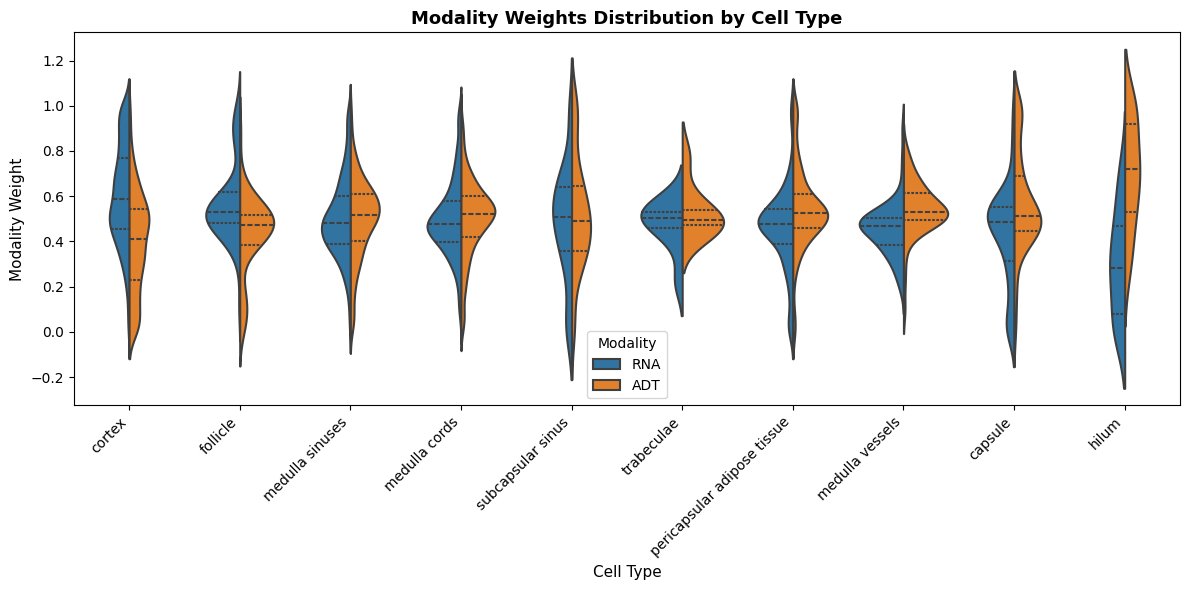

✓ Modality weights violin plot complete

Per cell-type mean weights:
                                RNA     ADT
capsule                      0.4315  0.5685
cortex                       0.6044  0.3956
follicle                     0.5679  0.4321
hilum                        0.3013  0.6987
medulla cords                0.4993  0.5007
medulla sinuses              0.5021  0.4979
medulla vessels              0.4579  0.5421
pericapsular adipose tissue  0.4583  0.5417
subcapsular sinus            0.4771  0.5229
trabeculae                   0.4715  0.5285


In [10]:
# Modality Weights Distribution by Cell Type (from tutorial)
import seaborn as sns

def plot_weight_value(alpha, label, modality1='RNA', modality2='ADT', order=None):
    """Plot modality weights distribution across cell types"""
    df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
    df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
    df['label'] = label
    df = df.set_index('label').stack().reset_index()
    df.columns = ['Cell_Type', 'Modality', 'Modality_Weight']
    
    fig, axes = plt.subplots(1, 1, figsize=(12, 6))
    ax = sns.violinplot(data=df, x='Cell_Type', y='Modality_Weight', hue="Modality",
                        split=True, inner="quart", linewidth=1.5, orient='v', order=order)
    ax.set_title('Modality Weights Distribution by Cell Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Cell Type', fontsize=11)
    ax.set_ylabel('Modality Weight', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Prepare data for plot
weights = cosmos_model.weights
cell_types_sorted = sorted(set(df_labels))
index_all = []
for cell_type in cell_types_sorted:
    idx = np.array([i for i in range(len(df_labels)) if df_labels[i] == cell_type])
    index_all.append(idx)

# Calculate mean weights per cell type
wghts_mean = np.mean(weights[index_all[0], :], 0)
for k in range(1, len(cell_types_sorted)):
    wghts_mean_temp = np.mean(weights[index_all[k], :], 0)
    wghts_mean = np.vstack([wghts_mean, wghts_mean_temp])

df_wghts_mean = pd.DataFrame(wghts_mean, columns=['RNA', 'ADT'], index=cell_types_sorted)

# Sort by RNA weight for better visualization
df_sort_mean = df_wghts_mean.sort_values(by=['RNA'], ascending=False)

# Create plot
plot_weight_value(weights, np.array(df_labels), modality1='RNA', modality2='ADT', order=list(df_sort_mean.index))

print("✓ Modality weights violin plot complete")
print(f"\nPer cell-type mean weights:")
print(df_wghts_mean.round(4))

## Key Results & Insights

In [11]:
# Extract insights

print("\n" + "="*70)
print("COSMOS INTEGRATION RESULTS (Paper Metrics)")
print("="*70)

print(f"\n1. CLUSTERING PERFORMANCE (Main Paper Metric)")
print(f"   Adjusted Rand Index (ARI): {best_ari:.4f}")
print(f"   - Measures clustering quality vs ground truth")
print(f"   - Range: [-1, 1], where 1 = perfect")
print(f"   - Optimal resolution: {best_res:.2f}")
print(f"   - Number of clusters: {len(set(adata_viz.obs['COSMOS']))}")
print(f"   - Number of cell types (ground truth): {len(label_type)}")

print(f"\n2. MODALITY WEIGHTS (WNN Component - Paper Innovation)")
print(f"   RNA weight: {np.mean(weights[:, 0]):.4f} ± {np.std(weights[:, 0]):.4f}")
print(f"   ADT weight: {np.mean(weights[:, 1]):.4f} ± {np.std(weights[:, 1]):.4f}")

# Per-cell modality dominance
mod1_dominant = np.sum(weights[:, 0] > weights[:, 1])
mod2_dominant = np.sum(weights[:, 1] > weights[:, 0])

print(f"\n3. CELL-TYPE SPECIFIC MODALITY PREFERENCE")
print(f"   Cells prefer RNA: {mod1_dominant} ({100*mod1_dominant/len(weights):.1f}%)")
print(f"   Cells prefer ADT: {mod2_dominant} ({100*mod2_dominant/len(weights):.1f}%)")
print(f"   → Key finding: Different cell types rely on different modalities")

print(f"\n4. EMBEDDING STATISTICS")
print(f"   Dimensions: {cosmos_model.embedding.shape[1]}")
print(f"   Mean: {np.mean(cosmos_model.embedding):.4f}")
print(f"   Std: {np.std(cosmos_model.embedding):.4f}")

print(f"\n5. DATASET INFORMATION")
print(f"   Total cells: {adata_viz.n_obs}")
print(f"   RNA genes: {adata1.n_vars}")
print(f"   ADT proteins: {adata2.n_vars}")
print(f"   Total features: {adata1.n_vars + adata2.n_vars}")

print(f"\n" + "="*70)
print(f"✓ COSMOS successfully integrated your 10x Lymph Node multi-omics data!")
print("="*70)


COSMOS INTEGRATION RESULTS (Paper Metrics)

1. CLUSTERING PERFORMANCE (Main Paper Metric)
   Adjusted Rand Index (ARI): 0.2489
   - Measures clustering quality vs ground truth
   - Range: [-1, 1], where 1 = perfect
   - Optimal resolution: 0.25
   - Number of clusters: 6
   - Number of cell types (ground truth): 10

2. MODALITY WEIGHTS (WNN Component - Paper Innovation)
   RNA weight: 0.5136 ± 0.1991
   ADT weight: 0.4864 ± 0.1991

3. CELL-TYPE SPECIFIC MODALITY PREFERENCE
   Cells prefer RNA: 1680 (48.2%)
   Cells prefer ADT: 1802 (51.7%)
   → Key finding: Different cell types rely on different modalities

4. EMBEDDING STATISTICS
   Dimensions: 50
   Mean: 0.0301
   Std: 0.1108

5. DATASET INFORMATION
   Total cells: 3484
   RNA genes: 18085
   ADT proteins: 31
   Total features: 18116

✓ COSMOS successfully integrated your 10x Lymph Node multi-omics data!
